# Gene Expression Peak-Trough analysis using Polar Plots

April 8, 2024

Analyze the chromatin at genes during peak and trough gene expression.

In [9]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Polar Plot

Goal: Classify genes by their peak and trough gene expression
    
Separately for Mother and Daughter Cells

Output:
1. Time and phase of peak gene expression
2. Time and phase of trough gene expression


In [18]:
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()

In [ ]:
#ge_analysis.ptrs_ret_df.to_csv('output/gene_expression_ptrs_with_tps_combined_model_2024_04_05.csv')

In [ ]:
from src.peak_to_trough import compute_ptr

In [19]:
from src.timer import Timer

timer = Timer()
ge_analysis.compute_ptr_inds_tps()
timer.print_time()


00:00:18.609


In [86]:
c_indices = np.concatenate([config.phase_columns['CG1'], 
                              config.phase_columns['postG1']])
d_indices = np.concatenate([config.phase_columns['DG1'], 
                              config.phase_columns['postG1']])

c_timepoints = config.get_timepoints_for_branch('t')
d_timepoints = config.get_timepoints_for_branch('b')

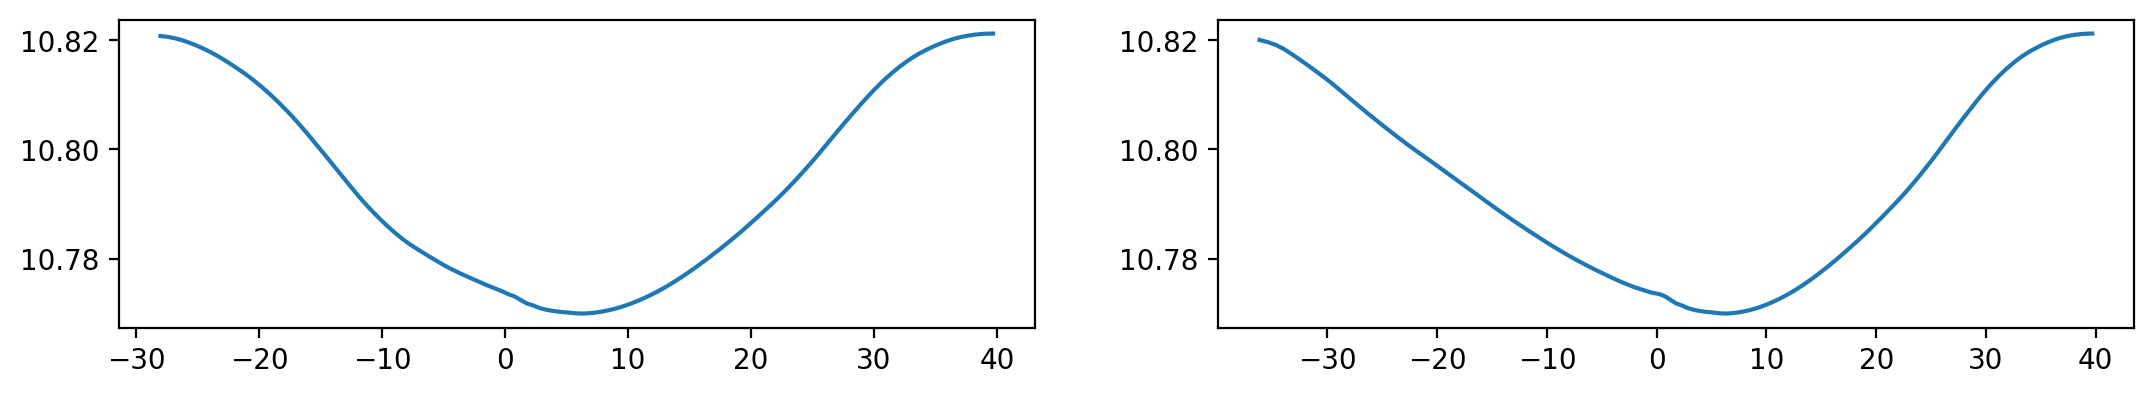

In [155]:
f = ge_analysis.gene_expression_f.loc['YPR198W']

plt.figure(figsize=(13, 2))
plt.subplot(1, 2, 1)
plt.plot(c_timepoints, f[c_indices])

plt.subplot(1, 2, 2)
plt.plot(d_timepoints, f[d_indices])

In [151]:
# Refactored to use min max values rather than peak and trough values
# todo: indices of 225 do not have a phase and need to be fixed

ge_analysis.compute_ptr_maxmins_tps()

In [158]:
ge_analysis.ptrs_min_maxs.head()

,mother_ptr,daughter_ptr,ptr,min_value,min_f_idx,min_tp,min_phase,max_value,max_f_idx,max_tp,max_phase
orf_name,,,,,,,,,,,
YAL067W-A,1.000799,1.003462,1.001686,4.436323733130215,127,-14.6021,D_G1,4.462289453606121,49,-28.0,C_G1
YAL067C,1.270735,3.001155,1.692257,8.653574920824855e-05,142,-3.4408,D_G1,10.387151140225065,174,13.9203,D_S
YAL064C-A,1.001099,1.001060,1.001086,5.1379068842125335,183,18.4672,D_G2M,5.146047281447994,63,-19.9201,C_G1
YAL064W,1.000021,1.004584,1.001539,5.021179679450736,123,-17.5784,D_G1,5.05580053372813,151,2.3004,D_S
YAL063C-A,1.000785,1.003663,1.001743,5.917611873407651,126,-15.3462,D_G1,5.950668244468483,221,37.6653,D_G2M


In [161]:
# Let's create a box plot of the ptr values for each peak phase

def get_quantile_values(ge_analysis, phases):
    ptrs_ret_df = ge_analysis.ptrs_min_maxs
    values = ptrs_ret_df[ptrs_ret_df['max_phase'].isin(phases)].ptr.values
    q25, med, q75 = tuple(np.quantile(values, [0.25, 0.5, 0.75]))
    
    iqr = q75 - q25
    
    lower_whisker_end = q25-iqr*1.5
    upper_whisker_end = q75+iqr*1.5    
    
    lower_whisker = values[values > lower_whisker_end].min()
    upper_whisker = values[values < upper_whisker_end].max()
    
    return lower_whisker, q25, med, q75, upper_whisker, iqr, len(values)


In [162]:
cg1_qs = get_quantile_values(ge_analysis, ['C_G1'])
dg1_qs = get_quantile_values(ge_analysis, ['D_G1'])
s_qs = get_quantile_values(ge_analysis, ['D_S', 'C_S'])
g2m_qs = get_quantile_values(ge_analysis, ['D_G2M', 'C_G2M'])

ptr_qs_dat = np.stack([cg1_qs, dg1_qs, s_qs, g2m_qs])
ptr_phase_qs_df = pd.DataFrame(ptr_qs_dat, index=['CG1', 'DG1', 'S', 'G2M'],
            columns=['lower_whisker', 'q25', 'median', 'q75', 'upper_whisker',
                     'iqr', 'n'])


In [163]:
ptr_phase_qs_df['plot_index'] = np.arange(len(ptr_phase_qs_df))

In [165]:
ptr_phase_qs_df

,lower_whisker,q25,median,q75,upper_whisker,iqr,n,plot_index
CG1,1.000002,1.003166,1.005157,1.030031,1.069739,0.026865,1142.0,0
DG1,1.000001,1.003967,1.006851,1.046521,1.108981,0.042554,875.0,1
S,1.000000,1.002019,1.015778,1.054923,1.134097,0.052904,1146.0,2
G2M,1.000001,1.002609,1.005110,1.014801,1.033069,0.012192,2412.0,3


(0.95, 1.2)

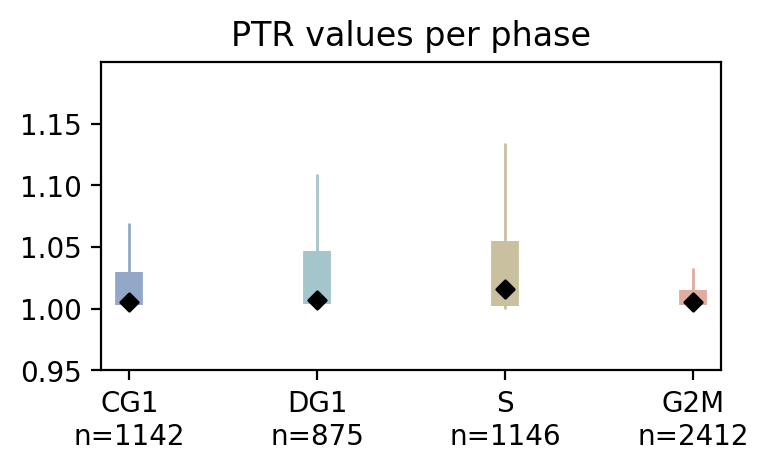

In [166]:
from src.model import color_for_key
plt.figure(figsize=(4, 2))

for idx, row in ptr_phase_qs_df.iterrows():
    color = color_for_key(idx)
    plt.plot([row.plot_index, row.plot_index],
             [row['q25'], row['q75']], lw=10, solid_capstyle='butt', zorder=1, c=color)
    plt.plot([row.plot_index, row.plot_index],
            [row['lower_whisker'], row['upper_whisker']], lw=1, solid_capstyle='butt', zorder=1, c=color)
    plt.scatter(row.plot_index, row['median'], c='black', zorder=10, s=20, marker='D')
    
    
xtick_names = [f"{ptr_phase_qs_df.index.values[i]}\nn={ptr_phase_qs_df.n.values[i]:.0f}" 
               for i in range(len(ptr_phase_qs_df))]

plt.xticks(ptr_phase_qs_df.plot_index, xtick_names)
plt.title("PTR values per phase")

plt.yticks(np.arange(0.9, 1.2, 0.05))
plt.ylim(0.95, 1.2)


Text(0.5, 1.0, 'Gene counts with PTR > threshold: 1.25')

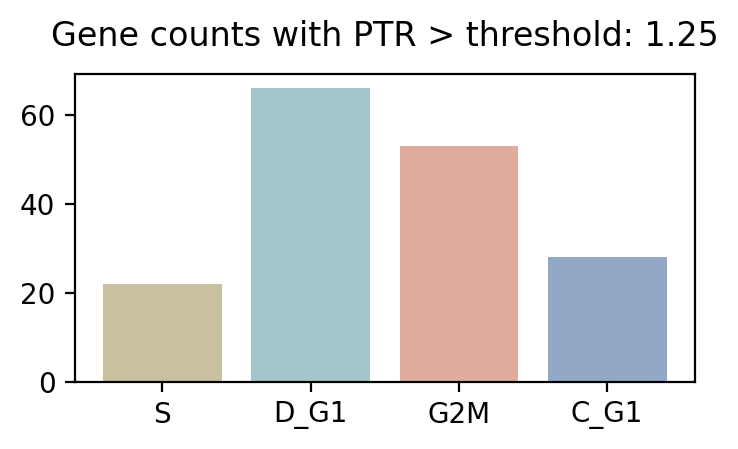

In [378]:
thresholded_ptrs, format_str, phase_counts = ge_analysis.threshold_ptrs(1.25)
from src.model import color_for_key

plt.figure(figsize=(4, 2))
phase_counts_df = pd.DataFrame(phase_counts, index=['counts']).T
colors = [color_for_key(key) for key in phase_counts_df.index.str.replace('_', '')]
plt.bar(phase_counts_df.index, phase_counts_df['counts'], 
        color=colors)

plt.title(f"Gene counts with PTR > threshold: {ge_analysis.ptr_threshold}", pad=10)


Text(0.5, 1.0, 'Distribution of deconvolved\ngene expression PTRs')

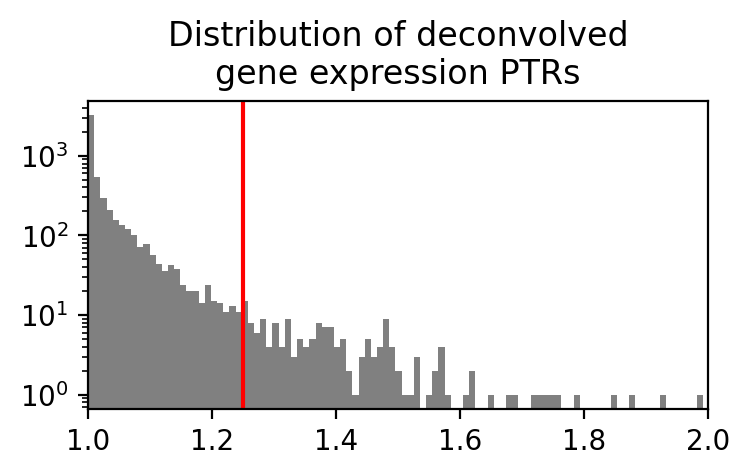

In [379]:
plt.figure(figsize=(4, 2))
plt.hist(ge_analysis.ptrs_ret_df.ptr, bins=100, color='gray')
plt.axvline(ge_analysis.ptr_threshold, c='red')
plt.xlim(1, 2)
plt.yscale('log')
plt.title("Distribution of deconvolved\ngene expression PTRs")


In [380]:
selected_genes = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
xin_dg1_genes = ['ASH1','EGT2','AMN1','DSE3','DSE4','PRY3','SCW11','DSE1','DSE2','CTS1']

Text(0.5, 1.0, 'Gene expression PTR per cell-cycle phase')

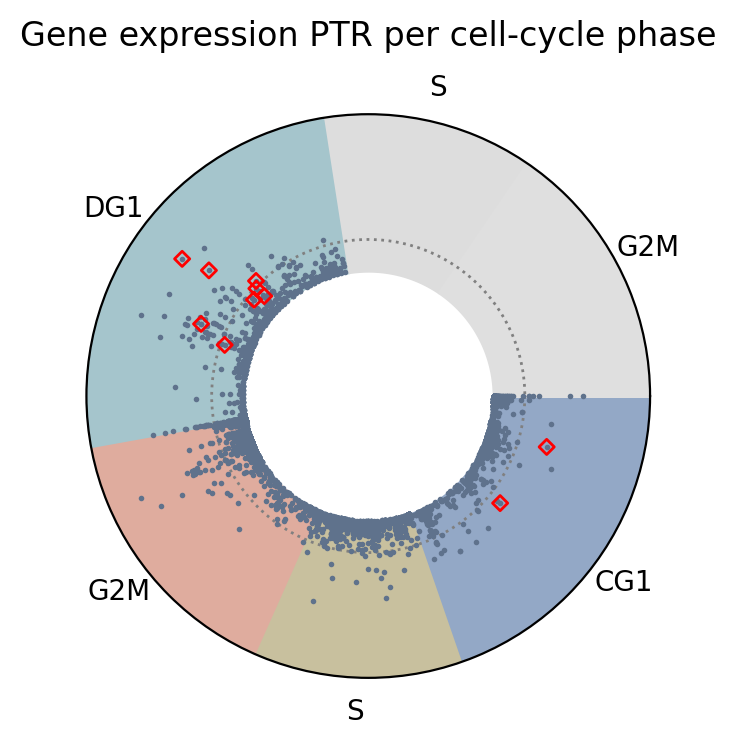

In [381]:
plotting_ptrs = ge_analysis.plot_scatter_polar_full(selected_genes=xin_dg1_genes)
plt.title("Gene expression PTR per cell-cycle phase", pad=10)

In [382]:
import glob 
from src.combined_chromatin_model import CombinedChromatinModel, \
    load_chromatin_model_from_disk

def get_ge_peak_trough_chrom_f(ge_analysis, orf_name):
    """From the gene expression analysis, get the peak and trough gene expression 
    points in the time series and plot how the chromatin looks for the given orf
    
    todo: create an analysis that allows us to aggregate sets of orf names.
    Plot examples from the set and an aggregate of the peak and trough images.
    """

    gene = ge_analysis.geneset.loc[orf_name]
    gene_ptr_row = ge_analysis.ptrs_min_maxs.loc[orf_name]

    # We need the peak and trough timepoint indices
    peak_idx, trough_idx = int(gene_ptr_row.max_f_idx), \
        int(gene_ptr_row.min_f_idx)

    # load the gene chromatin images F)
    chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'

    # todo: hard-coded as fixed image shape, move to global config
    image_shape = 8, 25
    
    f = load_chromatin_model_from_disk(orf_name, chromatin_dir, f_only=True)
    f_imgs = f.reshape((-1, *image_shape))
    
    return f_imgs[peak_idx], f_imgs[trough_idx]


In [383]:
sorted_thresh_ptr_genes = thresholded_ptrs.sort_values('ptr', ascending=False)
sorted_thresh_ptr_genes.head()

,mother_ptr,daughter_ptr,ptr,min_value,min_f_idx,min_tp,min_phase,max_value,max_f_idx,max_tp,max_phase
orf_name,,,,,,,,,,,
YMR030W-A,1.980067,2.014435,1.991458,4.310635286891881,143,-2.6967,D_G1,11.165940009955655,214,34.1288,D_G2M
YGR109C,1.807269,2.191140,1.927105,4.97934070295855,221,37.6653,D_G2M,20.143549219109342,114,-24.2752,D_G1
YMR032W,1.931803,1.759401,1.872536,7.084236660436009,150,1.7952,D_S,16.68717737254636,211,32.6132,D_G2M
YNL327W,1.524414,2.706399,1.845862,7.319236727452595,185,19.4777,D_G2M,26.757958990503376,123,-17.5784,D_G1
YKL164C,1.607703,2.207496,1.786914,8.056651071379237,182,17.962,D_G2M,22.250693431015957,118,-21.2988,D_G1


In [384]:
# Get the aggregate peaks and trough images for a set of genes
# to observe the chromatin differences between peaks and troughs of 
# the expressed gene set

def retrieve_selected_aggregate_fs_for_ptr_set(ge_analysis, selected_orf_names):

    strands = ge_analysis.geneset.loc[selected_orf_names].strand

    selected_peak_fs = None
    selected_trough_fs = None

    k = len(selected_orf_names)

    for i in range(k):
        orf_name = selected_orf_names[i]

        try: 
            peak_f, trough_f = get_ge_peak_trough_chrom_f(ge_analysis, orf_name)
        except IndexError:
            print(f"No f file for: {orf_name}. Skipping")
            continue

        strand = strands.loc[orf_name]

        if strand == '-':
            peak_f = np.fliplr(peak_f)
            trough_f = np.fliplr(trough_f)

        if selected_peak_fs is None:
            aggregate_peaks = np.zeros_like(peak_f)
            aggregate_troughs = np.zeros_like(trough_f)

            selected_peak_fs = np.zeros((k, *peak_f.shape))
            selected_trough_fs = np.zeros((k, *peak_f.shape))

        selected_peak_fs[i] = peak_f
        selected_trough_fs[i] = trough_f

    aggregate_peaks = selected_peak_fs.mean(axis=0)
    aggregate_troughs = selected_trough_fs.mean(axis=0)
    return aggregate_peaks, aggregate_troughs, selected_peak_fs, selected_trough_fs

In [385]:
def plot_aggregate(sel_orfs, name):
    (aggregate_peaks, 
     aggregate_troughs, 
     selected_peak_fs, 
     selected_trough_fs) = retrieve_selected_aggregate_fs_for_ptr_set(ge_analysis, sel_orfs)

    num_examples = 4
    fig, axs = plt.subplots(2, num_examples+1, figsize=(13, 3))
    plt.subplots_adjust(hspace=0.5)
    
    axs = np.array(axs)
    peak_axs = axs[0]
    trough_axs = axs[1]

    def plot_im(ax, dat):
        ax.imshow(dat, origin='lower', cmap='magma_r', vmax=30, aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axvline(9, c='black', lw=1) # todo: hard-coded tss location

    plot_im(peak_axs[0], aggregate_peaks)
    peak_axs[0].set_ylabel("Peak")

    plot_im(trough_axs[0], aggregate_troughs)
    trough_axs[0].set_ylabel("Trough")
    
    # --------- Individual examples -----------
    
    for i in range(num_examples):
        if i < len(selected_peak_fs):
            peak_axs[i+1].set_title(f"Ex. {i+1}")
            plot_im(peak_axs[i+1], selected_peak_fs[i])
            plot_im(trough_axs[i+1], selected_trough_fs[i])
        else:
            peak_axs[i+1].set_xticks([])
            trough_axs[i+1].set_xticks([])
            peak_axs[i+1].set_yticks([])
            trough_axs[i+1].set_yticks([])
    
    # -------- formating ----------------------

    peak_axs[0].set_title(f"Aggregate {name}\nn={len(sel_orfs)}")


In [386]:
# Examine the aggregate plots for the DG1, CG1, G2M, S genes

dg1_ptr_genes = sorted_thresh_ptr_genes[sorted_thresh_ptr_genes['max_phase'] == 'D_G1']
cg1_ptr_genes = sorted_thresh_ptr_genes[sorted_thresh_ptr_genes['max_phase'] == 'C_G1']
s_ptr_genes = sorted_thresh_ptr_genes[(sorted_thresh_ptr_genes['max_phase'] == 'C_S')
                                     | (sorted_thresh_ptr_genes['max_phase'] == 'D_S')]
g2m_ptr_genes = sorted_thresh_ptr_genes[(sorted_thresh_ptr_genes['max_phase'] == 'C_G2M')
                                     | (sorted_thresh_ptr_genes['max_phase'] == 'D_G2M')]

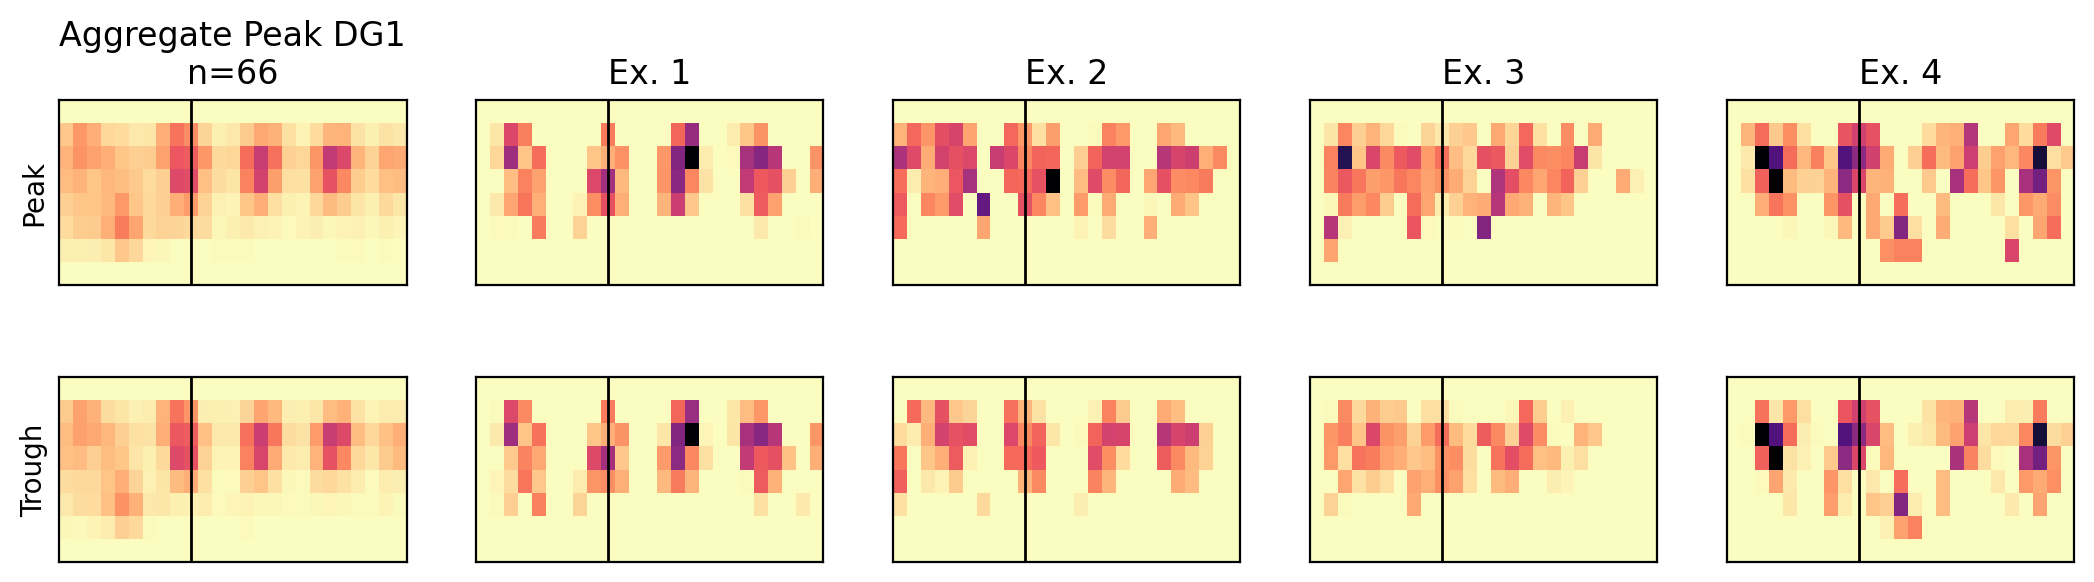

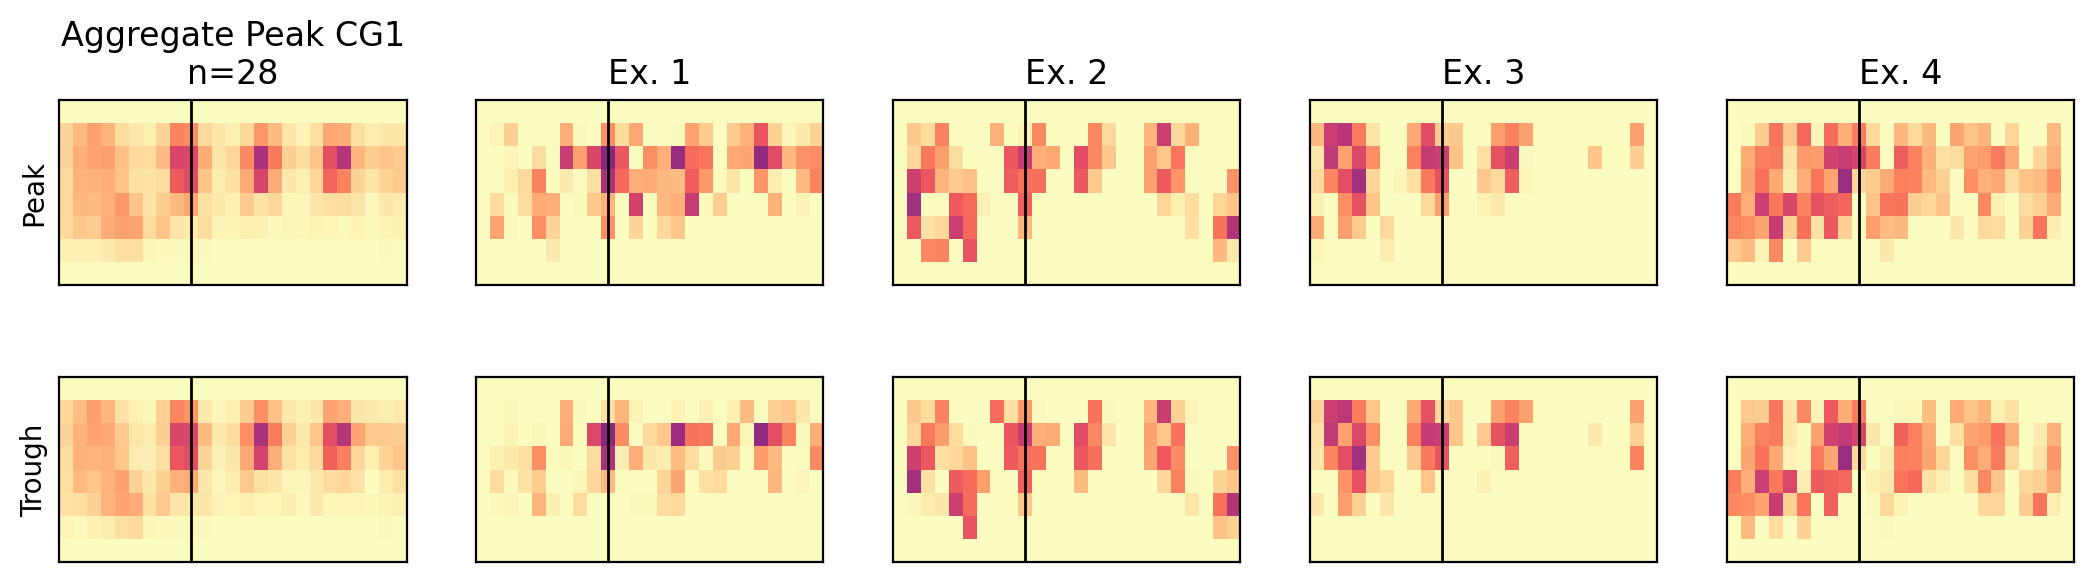

In [387]:
plot_aggregate(dg1_ptr_genes.index.values, "Peak DG1")
plot_aggregate(cg1_ptr_genes.index.values, "Peak CG1")

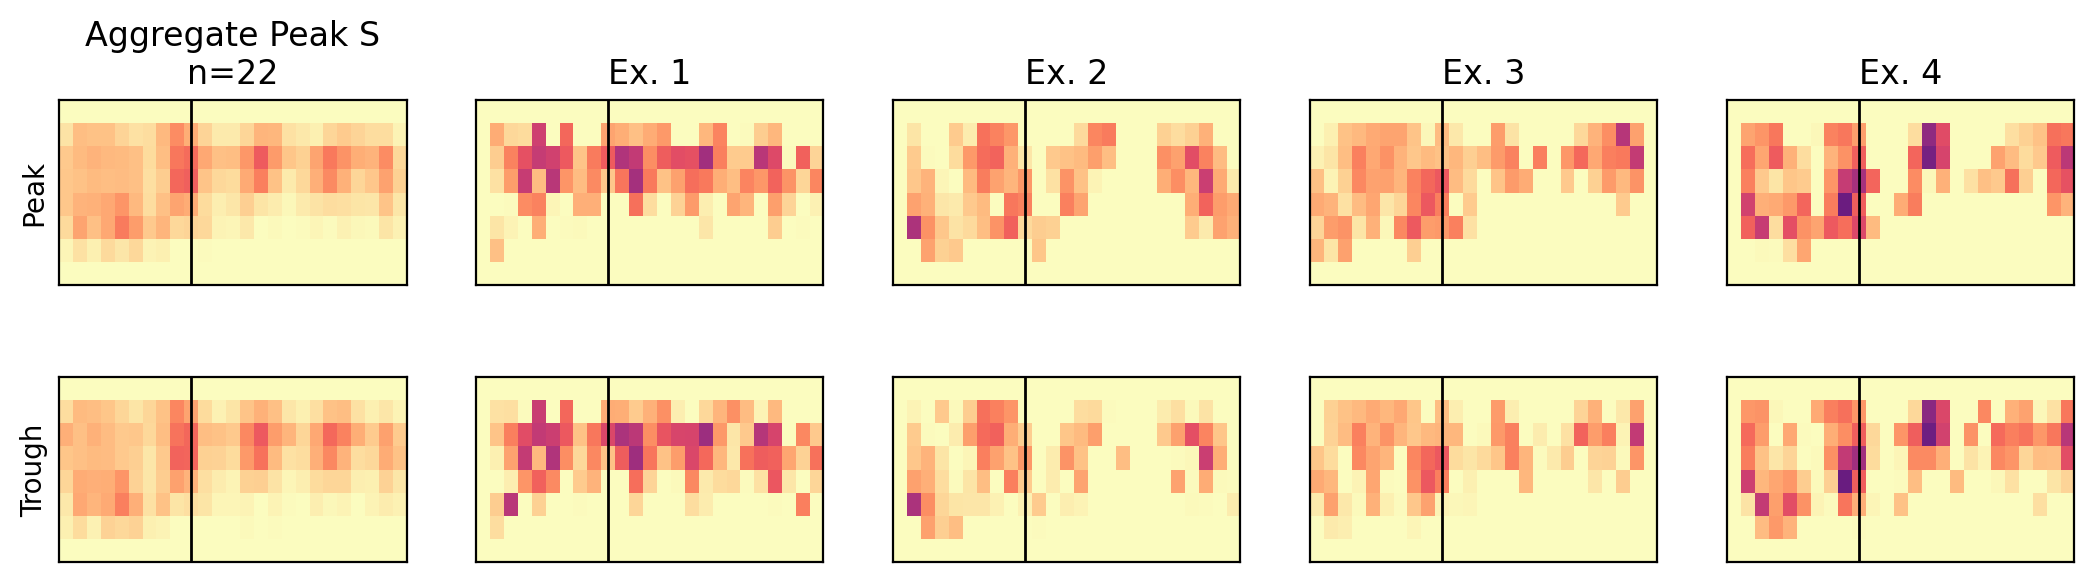

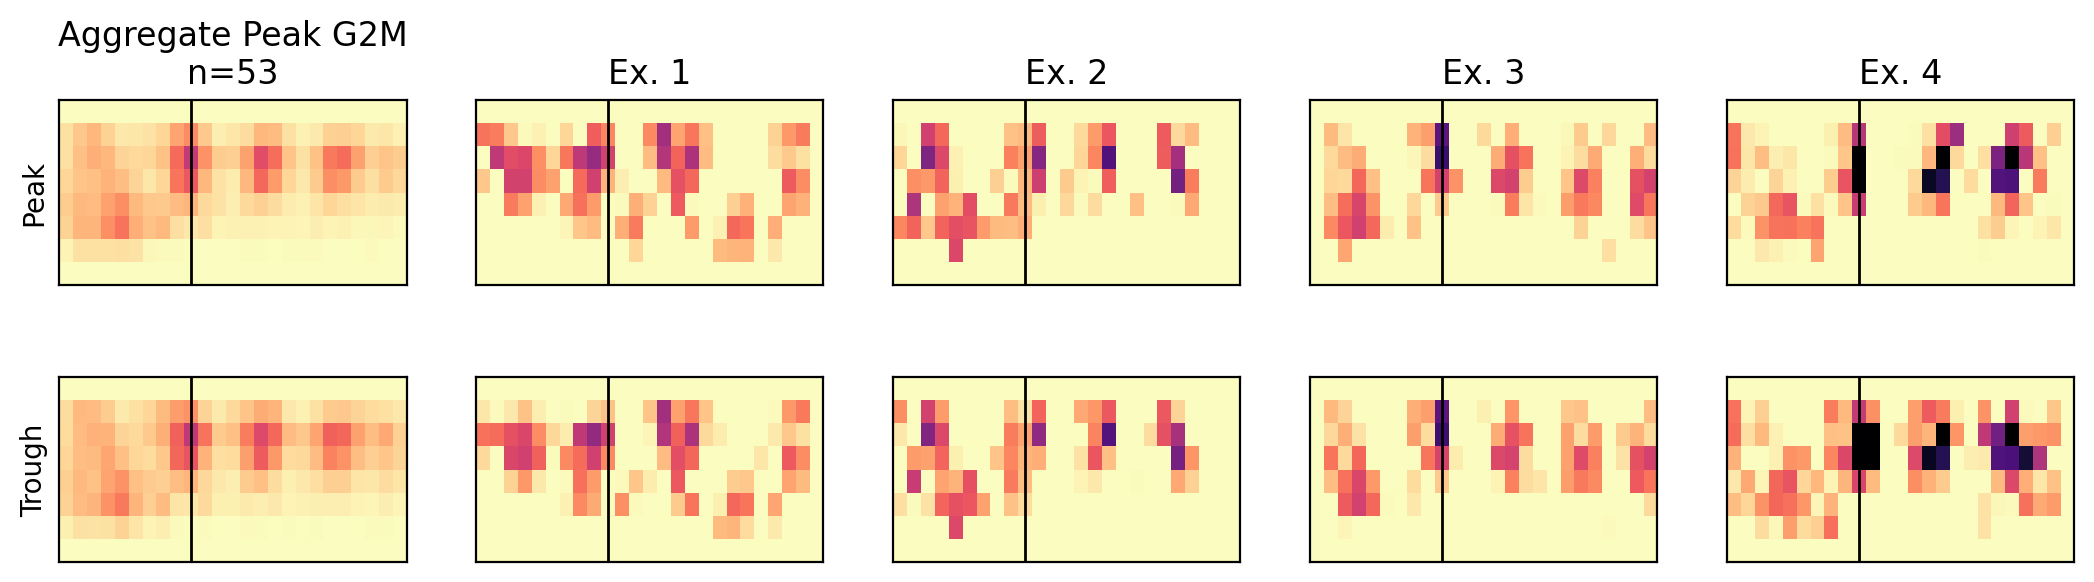

In [388]:
plot_aggregate(s_ptr_genes.index.values, "Peak S")
plot_aggregate(g2m_ptr_genes.index.values, "Peak G2M")

# Promoter small fragments analysis

Now let's choose a window for the transcription factor binding in the promoter
and start some analysis in which we characterize the occupancy changes 
for the promoters for each gene

Goals: 
- Analyze the timing of the promoter small fragments
- Plot a few example curves
- Compute the ptr and max and min locations for promoter occupancy
- Compare with gene expression
    - todo: ptr, other ideas to compare timing


In [531]:
from src.global_config import GlobalConstants

# Using the DG1 aggregate genes as an example

sel_orfs = dg1_ptr_genes.index.values
(aggregate_peaks, 
     aggregate_troughs, 
     selected_peak_fs, 
     selected_trough_fs) = retrieve_selected_aggregate_fs_for_ptr_set(ge_analysis, 
    dg1_ptr_genes.index.values)


In [532]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

Promoter range:  (-192, -64)
Small fragments lengths:  (32, 96)


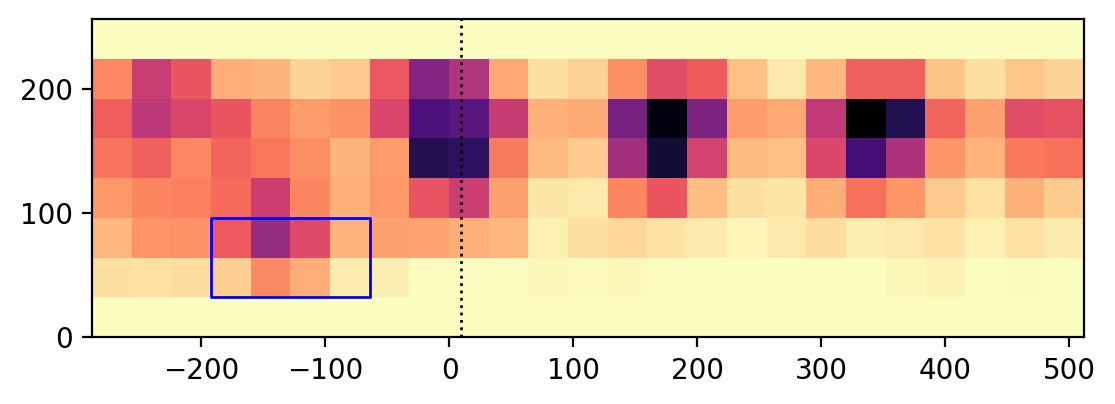

In [533]:
plt.imshow(aggregate_peaks, origin='lower', cmap='magma_r',
          extent=GlobalConstants.BIN_EXTENTS)
plt.axvline(9, lw=1, c='black', ls='dotted')

from src.orf_plotter import plot_rect

ax = plt.gca()

prom_x, prom_len = promoter_analysis.prom_x, promoter_analysis.prom_len
sm_lens, sm_range = promoter_analysis.sm_lens, promoter_analysis.sm_range

plot_rect(ax, prom_x[0], sm_lens[0], prom_len, sm_range, 
          edgecolor='blue', fill=False, lw=1, zorder=10)

print(f"Promoter range: ", prom_x)
print(f"Small fragments lengths: ", sm_lens)

In [534]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.162
1001/5574 - 00:00:06.934
2001/5574 - 00:00:12.307
3001/5574 - 00:00:17.549
4001/5574 - 00:00:22.554
5001/5574 - 00:00:27.570


In [564]:
promoter_analysis.compute_small_fragments_promoter_occupancy()

In [ ]:
promoter_analysis.compute_ptr_min_maxes()

In [ ]:
promoter_analysis.promoter_min_maxs

In [ ]:
# Compute a polar plot of the ptrs and max locations

# Compare to the gene expression plot, does it look much different
# If similar, where are the peaks? Near the gene expression maxes?

# How do we compare the similarities and differences between the two?

# Expect the PTRs to be different, but for a handful, it will they will be similar
# and we can zoom in on them

    # This set of genes could be zoomed in on and analyzed as a time delta between 
    # promoter occupancy and gene expression changes.
